In [129]:
# 라이브러리 호출
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import platform

warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

In [130]:
df = pd.read_csv("DieCasting_Quality_Raw_Data.csv", header=[0,1])
df.head()

Process                                                                   \
       id Product_Type Shot Velocity_1 Velocity_2 Velocity_3 High_Velocity   
0       1            1    1      0.144      0.170      0.188         2.134   
1    1002            1    2      0.144      0.170      0.182         2.124   
2    2003            1    3      0.144      0.170      0.182         2.116   
3    3004            1    4      0.144      0.170      0.182         2.137   
4    4005            1    5      0.144      0.172      0.176         2.111   

                                                                        \
  Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness  Clamping_Force    
0               214           0.008                 10             258   
1               217           0.008                 11             257   
2               214           0.008                 11             257   
3               217           0.008                 11             257   
4               217           0.008                 12             257   

                                                                           \
  Cycle_Time  Pressure_Rise_Time Casting_Pressure Spray_Time Spray_1_Time   
0       20.7               0.044             1037        7.8          0.7   
1       20.7               0.044             1052        7.8          0.7   
2       20.8               0.041             1037        7.8          0.7   
3       20.7               0.043             1051        7.8          0.7   
4       20.7               0.042             1052        7.8          0.7   

                             Sensor                                \
  Spray_2_Time Melting_Furnace_Temp Air_Pressure Air_Pressure_Min   
0          0.8                695.0          6.3                3   
1          0.8                696.4          6.3                3   
2          0.8                696.4          6.3                3   
3          0.8                696.4          6.3                3   
4          0.8                697.9          6.4                3   

                                                                   \
  Air_Pressure_Max Coolant_Temp Coolant_Temp_Min Coolant_Temp_Max   
0                9         26.0               10               50   
1                9         26.1               10               50   
2                9         26.1               10               50   
3                9         26.1               10               50   
4                9         26.1               10               50   

                                                                   \
  Coolant_Pressure Factory_Temp Factory_Temp_Min Factory_Temp_Max   
0             2.71         32.9             18.0             22.0   
1             2.69         32.9             18.0             22.0   
2             2.69         32.9             18.0             22.0   
3             2.69         32.9             18.0             22.0   
4             2.69         32.9             18.0             22.0   

                                                                  Defects  \
  Factory_Humidity Factory_Humidity_Min Factory_Humidity_Max Short_Shot_1   
0             58.4                 18.0                 22.0            0   
1             58.2                 18.0                 22.0            0   
2             58.2                 18.0                 22.0            0   
3             58.2                 18.0                 22.0            0   
4             57.8                 18.0                 22.0            0   

                                                                   \
  Bubble_1 Exfoliation_1 Blow_Hole_1 Stain_1 Dent_1 Deformation_1   
0        0             0           0       0      0             0   
1        0             0           0       0      0             0   
2        0             0           0       0      0             0   
3        0             1           0       0      0        

---
## 6 컬럼 구조 확인

#### Process 컬럼 (17개)
- 다이캐스팅 공정에서 설정한 조건(속도·압력·시간·형체력 등)을 모아둔 변수
1. id: 설비/레코드 식별자(ID)
2. Product_Type: 제품 유형을 1/2로 구분한 코드
3. Shot: 생산 순서(샷 번호)
4. Velocity_1: 금형에 용탕을 투입(사출)하는 속도(1단)
5. Velocity_2: 사출 속도 2단(중간 구간 속도)
6. Velocity_3: 사출 속도 3단(후반 구간 속도)
7. High_Velocity: 사출 과정에서의 최고 속도(피크)
8. Cylinder_Pressure: shot을 찍기 위한 실린더 압력이다.
9. Rapid_Rise_Time: 실린더 압력 상승 시간(압력이 급히 올라가는 데 걸린 시간)이다. 
10. Biscuit_Thickness: 주조 후 샷 슬리브에 남는 주조 비스켓(잔류 금속) 두께다. 
11. Clamping_Force: shot을 찍을 때 금형을 밀어주는 형체력(클램핑 힘)
12. Cycle_Time: 제품이 나오기까지 걸리는 총 사이클 시간
13. Pressure_Rise_Time: 압력이 목표치로 올라가는 데 걸린 시간
14. Casting_Pressure: shot을 찍을 때의 주조 압력
15. spray_Time: 스프레이 작업에 걸린 전체 시간
16. Spray_1_Time: 스프레이 1단 구간 시간
17. Spray_2_Time: 스프레이 2단 구간 시간

#### Sensor 컬럼(14)
- 설비/환경이 실제로 측정한 상태값(온도·압력·습도 등)을 모아둔 센서 변수
1. Melting_Furnace_Temp: 용해로(용탕) 온도
2. Air_Pressure: 공압(에어) 라인 압력 (스프레이/블로우/공압 구동 안정성 신호로 해석 가능)
3. Air_Pressure_Min: 해당 구간에서 기록된 에어 압력 최소값
4. Air_Pressure_Max: 해당 구간에서 기록된 에어 압력 최대값
5. Coolant_Temp: 냉각수 온도
6. Coolant_Temp_Min: 해당 구간 냉각수 온도 최소값
7. Coolant_Temp_Max: 해당 구간 냉각수 온도 최대값
8. Coolant_Pressure: 냉각수 압력
9. Factory_Temp: 공장(주변 환경) 온도
10. Factory_Temp_Min: 공장 온도 최소값
11. Factory_Temp_Max: 공장 온도 최대값
12. Factory_Humidity: 공장(주변 환경) 습도
13. Factory_Humidity_Min: 공장 습도 최소값
14. Factory_Humidity_Max: 공장 습도 최대값 

#### Defects 컬럼 (26)
- 각 샷의 검사 결과로 확인된 불량 라벨
- _1/_2는 캐비티 1/2(금형의 두 캐비티) 를 뜻한다.
- 값은 보통 0=정상, 1=불량 발생
- 2 이상이 존재함 (이는 발생 있음 으로 취급해도 무관하다 판단)
1. Short_Shot_1: 미성형(충전 부족) 불량
2. Short_Shot_2: 미성형(충전 부족) 불량
3. Bubble_1: 기포 불량
4. Bubble_2: 기포 불량 
5. Exfoliation_1: 박리(층 분리/벗겨짐) 불량 
6. Exfoliation_2: 박리(층 분리/벗겨짐) 불량 
7. Blow_Hole_1: 블로홀/기공 불량 
8. Blow_Hole_2: 블로홀/기공 불량 
9. Stain_1: 얼룩 불량 
10. Stain_2: 얼룩 불량 
11. Dent_1: 찍힘/눌림 불량 
12. Dent_2: 찍힘/눌림 불량 
13. Scratch_1: 스크래치 불량 
14. Scratch_2: 스크래치 불량 
15. Buring_Mark_1: 번마크/그을림 불량 
16. Buring_Mark_2: 번마크/그을림 불량 
17. Deformation_1: 변형 불량 
18. Deformation_2: 변형 불량 
19. Crack_1: 균열 불량 
20. Crack_2: 균열 불량 
21. Contamination_1: 오염(이물) 불량 
22. Contamination_2: 오염(이물) 불량 
23. Impurity_1: 불순물 불량 
24. Impurity_2: 불순물 불량 
25. Inclusions_1: 개재물(내부 이물) 불량 
26. Inclusions_2: 개재물(내부 이물) 불량 

불량 분류에 대한 이야기\
불량 유형이 너무 많고, 희소한 유형도 있는것 같다.\
주로 나타나는 불량 4~5종 + 그외 불량기준으로 재분류해서 사용하기
(Short_Shot 등)

1. 식별/메타\
Process: id, Shot, Product_Type
Sensor: (직접 대응 없음)\
해석: 공정 상태를 설명/구분

2. 속도 프로파일 (사출 속도)\
Process: Velocity_1, Velocity_2, Velocity_3, High_Velocity\
Sensor: (직접 대응 센서 없음)\
충전 동작을 어떤 속도로 밀어 넣었는지

3. 압력/가압 (밀어넣기 + 가압 유지)\
Process: Cylinder_Pressure, Casting_Pressure\
Sensor: (직접 대응 센서 없음)\
용탕을 밀어 넣는 힘과 충전 이후 가압 유지 강도

4. 변화 속도\
Process: Rapid_Rise_Time, Pressure_Rise_Time\
Sensor: (직접 대응 센서 없음)\
설정값의 크기보다 전환이 빠른지/완만한지

5. 금형 체결(버티는 힘)\
Process: Clamping_Force\
Sensor: (직접 대응 센서 없음)\
금형이 벌어지지 않게 버티지

6. 금형 준비/이형/블로우
Process: spray_Time, Spray_1_Time, Spray_2_Time\
Sensor: Air_Pressure, Air_Pressure_Min, Air_Pressure_Max\
금형 표면 준비 단계의 작업량(스프레이 시간) + 공압 구동 안정성(공압 라인 상태로 해석 가능)

7. 냉각
Process: Cycle_Time\
Sensor: Coolant_Temp, Coolant_Temp_Min, Coolant_Temp_Max, Coolant_Pressure\
공정 템포(사이클)와 냉각 라인 상태(온도/압력)를 열관리 관점으로 보기

8. 공장 환경
Process: (직접 대응 없음)\
Sensor: Factory_Temp, Factory_Temp_Min, Factory_Temp_Max, Factory_Humidity, Factory_Humidity_Min, Factory_Humidity_Max\
설비 외부의 주변 환경 조건

9. 용탕/재료 열상태 블록
Process: (직접 대응 없음)\
Sensor: Melting_Furnace_Temp\
용탕의 열 상태

10. 잔류/충전 상태\
Process: Biscuit_Thickness\
Sensor: (직접 대응 없음)\
충전/주입 조건


In [131]:
# =========================
# 2) 메인 데이터 컬럼 구조 확인 (Process / Sensor / Defects)
# =========================
# MultiIndex 컬럼의 0레벨(최상위)의 컬럼들만 잘라서 가져옴
process_df = df.xs("Process", axis=1, level=0)
sensor_df  = df.xs("Sensor",  axis=1, level=0)
defects_df = df.xs("Defects", axis=1, level=0)

process_df.columns = process_df.columns.astype(str).str.strip()
sensor_df.columns  = sensor_df.columns.astype(str).str.strip()
defects_df.columns = defects_df.columns.astype(str).str.strip()

# 샷별 불량 개수(26개 defect 컬럼의 합)
defect_count = defects_df.sum(axis=1)
# (B) 이진 타겟(불량 하나라도 있으면 1)
y_any_defect = (defect_count > 0).astype(int)

In [133]:
col_uniques = defects_df.apply(lambda s: sorted(s.dropna().unique()))
col_uniques

Short_Shot_1          [0, 1, 2]
Bubble_1                 [0, 1]
Exfoliation_1         [0, 1, 2]
Blow_Hole_1        [0, 1, 2, 3]
Stain_1               [0, 1, 2]
Dent_1                   [0, 1]
Deformation_1         [0, 1, 2]
Contamination_1          [0, 1]
Impurity_1               [0, 1]
Crack_1                  [0, 1]
Scratch_1                [0, 1]
Buring_Mark_1            [0, 1]
Inclusions_1                [0]
Short_Shot_2          [0, 1, 2]
Bubble_2              [0, 1, 2]
Exfoliation_2         [0, 1, 2]
Blow_Hole_2           [0, 1, 2]
Stain_2                     [0]
Dent_2                   [0, 1]
Deformation_2         [0, 1, 2]
Contamination_2          [0, 1]
Impurity_2               [0, 1]
Crack_2                  [0, 1]
Scratch_2                   [0]
Buring_Mark_2               [0]
Inclusions_2             [0, 1]
dtype: object

## 불량품 유형 확인하기

In [ ]:
# 0보다 크면 불량(1)로 바꾸기
defects_df = defects_df.apply(pd.to_numeric, errors="coerce").fillna(0)
defects_df = (defects_df > 0).astype(int)
# defects_df = (defects_df > 0).astype(int) # 불량유형 지정 안됨

# cavity 1 / 2 컬럼 나누기
c1 = defects_df[[c for c in defects_df.columns if c.endswith("_1")]]
c2 = defects_df[[c for c in defects_df.columns if c.endswith("_2")]]

#  불량 유형 이름 통일(Short_Shot_1 -> Short_Shot)
c1.columns = [c.replace("_1", "") for c in c1.columns]
c2.columns = [c.replace("_2", "") for c in c2.columns]

# 발생률(%) 계산
rate1 = c1.mean() * 100
rate2 = c2.mean() * 100

# 보기 좋게 큰 순서로 정렬
order = (rate1 + rate2).sort_values(ascending=False).index
rate1 = rate1[order]
rate2 = rate2[order]

In [135]:
summary = pd.DataFrame({
    "Cavity1(%)": rate1, # 전체 샷 중에서 cavity1에서 그 불량이 나온 비율
    "Cavity2(%)": rate2, # 전체 샷 중에서 cavity2에서 그 불량이 나온 비율
    "Cavity_sum": rate1+rate2, # 캐비티 단위 발생률 합
})

summary

,Cavity1(%),Cavity2(%),Cavity_sum
Short_Shot,6.794957,2.415395,9.210352
Blow_Hole,3.251493,2.136695,5.388188
Exfoliation,2.322495,1.778368,4.100863
Stain,2.773723,0.000000,2.773723
Deformation,1.446583,0.862641,2.309224
Bubble,0.955541,0.119443,1.074983
Contamination,0.053086,0.106171,0.159257
Dent,0.092900,0.053086,0.145985
Impurity,0.026543,0.066357,0.092900
Buring_Mark,0.066357,0.000000,0.066357


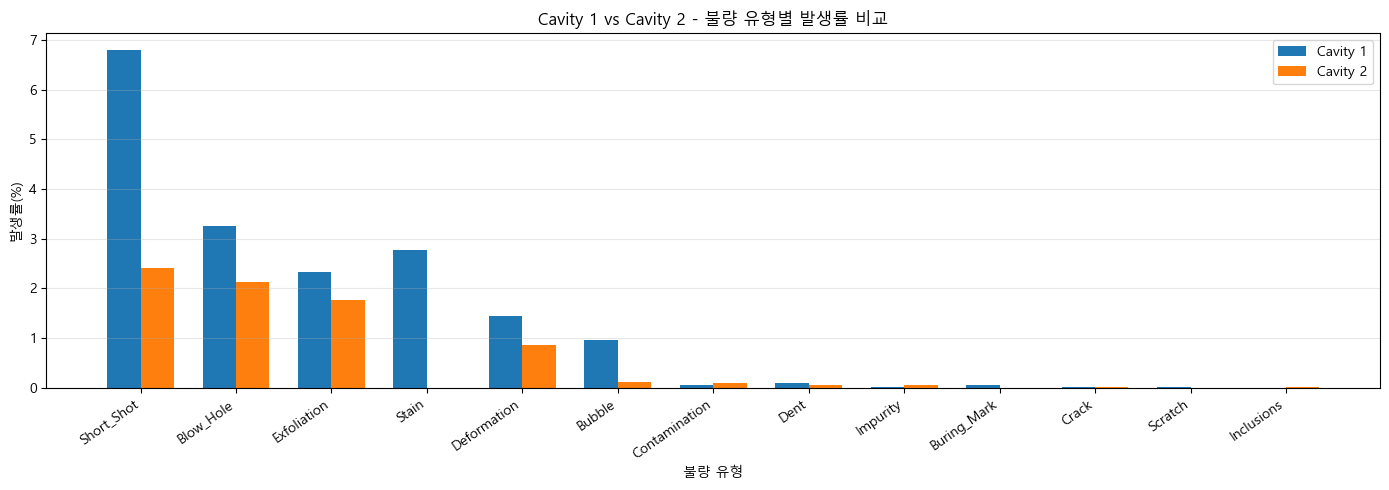

In [136]:
x = np.arange(len(order))
w = 0.35

plt.figure(figsize=(14, 5))
plt.bar(x - w/2, rate1.values, width=w, label="Cavity 1")
plt.bar(x + w/2, rate2.values, width=w, label="Cavity 2")

plt.title("Cavity 1 vs Cavity 2 - 불량 유형별 발생률 비교")
plt.xlabel("불량 유형")
plt.ylabel("발생률(%)")
plt.xticks(x, order, rotation=35, ha="right")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

1. Short_Shot: 미성형(충전 부족) 불량 — 용탕이 금형 끝까지 다 채워지지 않아 모서리/얇은 부위가 덜 찍히거나 일부가 비는 현상.
2. Bubble: 기포 불량 — 주조 중 갇힌 가스/공기가 내부나 표면에 기포로 남아 강도 저하·누설/외관 불량을 유발.
3. Exfoliation: 박리(층 분리/벗겨짐) 불량 — 표면층이 뜨거나 층이 분리되어 벗겨지는 형태로, 표면 품질·내구성을 크게 떨어뜨림.
4. Blow_Hole: 블로홀/기공 불량 — 응고 중 가스/수축으로 생긴 비교적 큰 공극(구멍)으로, 단면 기공·핀홀처럼 나타남.
5. Stain: 얼룩 불량 — 산화막/윤활제/오염 영향으로 표면 색이 불균일하게 남아 얼룩처럼 보이는 외관 불량.
6. Dent: 찍힘/눌림 불량 — 취출·이송·적재 과정에서 충격/압력으로 표면이 눌리거나 자국이 생긴 외관/치수 불량.
7. Scratch: 스크래치 불량 — 금형, 이송 설비, 공구, 적재 간 마찰로 표면에 선형 흠집이 생기는 외관 불량.
8. Buring_Mark: 번마크/그을림 불량 — 고온 가스/산화 영향으로 표면이 그을리거나 변색되는 현상(검게 타거나 갈변).
9. Deformation: 변형 불량 — 응고 후 취출·냉각·후공정 중 응력/열로 휘어짐·뒤틀림이 생겨 형상/치수가 틀어짐.
10. Crack: 균열 불량 — 응고수축·열응력·과도한 취출력 등으로 미세~육안 균열이 발생해 파손 위험이 커짐.
11. Contamination: 오염(이물) 불량 — 분진/오일/칩 등 외부 이물이 표면에 붙거나 끼어 도장·외관·조립성 문제를 만듦.
12. Impurity: 불순물 불량 — 용탕 내 불순 성분/산화물 등이 섞여 품질이 저하되고 표면 결함·취성 증가로 이어짐.
13. Inclusions: 개재물(내부 이물) 불량 — 산화막/슬래그 등 비금속물이 내부에 갇혀 단면에 점/덩어리로 보이며 강도를 약화.

1. Short_Shot: 미성형(충전 부족) 불량 — 용탕이 금형 끝까지 다 채워지지 않아 모서리/얇은 부위가 덜 찍히거나 일부가 비는 현상.
2. Blow_Hole: 블로홀/기공 불량 — 응고 중 가스/수축으로 생긴 비교적 큰 공극(구멍)으로, 단면 기공·핀홀처럼 나타남.
3. Exfoliation: 박리(층 분리/벗겨짐) 불량 — 표면층이 뜨거나 층이 분리되어 벗겨지는 형태로, 표면 품질·내구성을 크게 떨어뜨림.
4. Stain: 얼룩 불량 — 산화막/윤활제/오염 영향으로 표면 색이 불균일하게 남아 얼룩처럼 보이는 외관 불량.
5. Deformation: 변형 불량 — 응고 후 취출·냉각·후공정 중 응력/열로 휘어짐·뒤틀림이 생겨 형상/치수가 틀어짐.
6. Bubble: 기포 불량 — 주조 중 갇힌 가스/공기가 내부나 표면에 기포로 남아 강도 저하·누설/외관 불량을 유발.

Short_Shot, Blow_Hole, Exfoliation, Stain, Deformation

불량 판정(불량/양품)은 26개 중 하나라도 발생하면 불량으로 판정.\
대신 불량 유형은 분량 빈도? 중요도 기준으로 잡고, 나머지는 기타(Etc)로 묶어 클래스 수를 줄인다.

1. 빈도 기반으로 나누기 (값의 대표성)
2. 중요도 기반으로 나누기 (도메인)

Short_Shot (미성형/충전 부족)

Blow_Hole / Bubble (기공/가스 계열)

Exfoliation

Deformation

Stain

In [137]:
# 주요 불량, 나머진 기타로 잡음
major = ["Short_Shot", "Blow_Hole", "Exfoliation", "Stain", "Deformation"]

# 1) 표 만들기: 주요 5개는 그대로, 나머지는 Etc로 합치기
summary_major = summary.loc[major].copy()

etc_row = summary.drop(index=major).sum()   # Cavity1/2/합 컬럼 합쳐짐
summary_group = pd.concat([summary_major, pd.DataFrame([etc_row], index=["Etc"])])

# 보기 좋게(선택)
summary_group = summary_group[["Cavity1(%)", "Cavity2(%)", "Cavity_sum"]].round(6)

summary_group

,Cavity1(%),Cavity2(%),Cavity_sum
Short_Shot,6.794957,2.415395,9.210352
Blow_Hole,3.251493,2.136695,5.388188
Exfoliation,2.322495,1.778368,4.100863
Stain,2.773723,0.000000,2.773723
Deformation,1.446583,0.862641,2.309224
Etc,1.234240,0.384871,1.619111


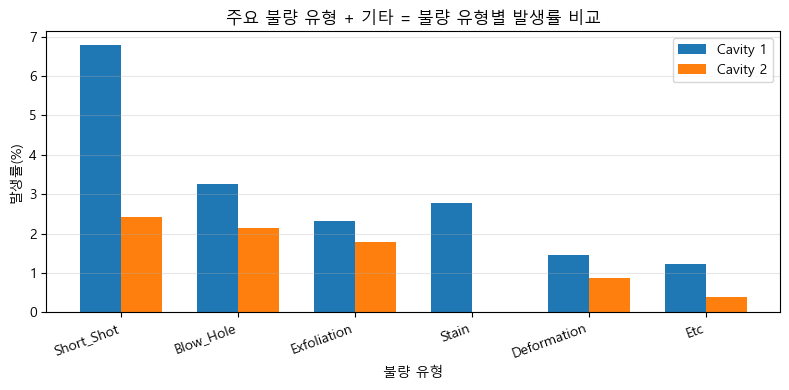

In [138]:
# 2) Major/Etc로 묶은 요약 표 (캐비티별도 같이)
labels = summary_group.index.tolist()
x = np.arange(len(labels))
w = 0.35

plt.figure(figsize=(8,4))
plt.bar(x - w/2, summary_group["Cavity1(%)"].values, width=w, label="Cavity 1")
plt.bar(x + w/2, summary_group["Cavity2(%)"].values, width=w, label="Cavity 2")

plt.title("주요 불량 유형 + 기타 = 불량 유형별 발생률 비교")
plt.xlabel("불량 유형")
plt.ylabel("발생률(%)")
plt.xticks(x, labels, rotation=20, ha="right")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 결측치 처리

In [139]:
# =========================
# 결측치(NA) 구조 확인 (+ 컬럼별 비율)
# =========================
print("===== 결측치(NA) 확인 =====")

n_rows = len(df)

na_count = df.isna().sum().sort_values(ascending=False)
na_cols = na_count[na_count > 0]

# 그룹별 결측치 개수(총 결측 수) - 기존 그대로
print("그룹별 결측치 합(총 결측 수):")
print(pd.Series({
    "Process": process_df.isna().sum().sum(),
    "Sensor":  sensor_df.isna().sum().sum(),
    "Defects": defects_df.isna().sum().sum()
}))
print()

# 컬럼별 결측치 개수
print("결측치가 있는 컬럼만(개수):")
print(na_cols)
print()

# 컬럼별 결측치 비율(%): (결측 행 수 / 전체 행 수) * 100
print("결측치가 있는 컬럼만(비율 %):")
print(((na_cols / n_rows) * 100).round(4))
print()

===== 결측치(NA) 확인 =====
그룹별 결측치 합(총 결측 수):
Process      0
Sensor     540
Defects      0
dtype: int64

결측치가 있는 컬럼만(개수):
Sensor  Factory_Temp            90
        Factory_Humidity        90
        Factory_Temp_Max        90
        Factory_Humidity_Max    90
        Factory_Humidity_Min    90
        Factory_Temp_Min        90
dtype: int64

결측치가 있는 컬럼만(비율 %):
Sensor  Factory_Temp            1.1944
        Factory_Humidity        1.1944
        Factory_Temp_Max        1.1944
        Factory_Humidity_Max    1.1944
        Factory_Humidity_Min    1.1944
        Factory_Temp_Min        1.1944
dtype: float64



Factory_Temp: 공장(주변 환경) 온도\
Factory_Humidity: 공장(주변 환경) 습도\
Factory_Temp_Max: 공장 온도 최대값\
Factory_Temp_Min: 공장 온도 최소값\
Factory_Humidity_Max: 공장 습도 최대값\
Factory_Humidity_Min: 공장 습도 최소값


선택지 1. 삭제하기\
특정 센서(공장 환경)만 빠진 케이스라 분석을 크게 해치지 않을 가능성이 존재

선택지 2. 결측을 대체 혹은 플래그 추가\
median이 제일 무난

## 이상치 처리

In [ ]:
# 이상치 기준: 왜도 < |2|, 첨도 < |8| 범위에 하나라도 못 맞추면 → IQR 사용
# 
#

In [177]:
# =========================
# 1) 왜도/첨도 계산
# - pandas kurt() = excess kurtosis (정규분포=0)
# =========================
proc_skew = process_df.skew(skipna=True)
proc_kurt = process_df.kurt(skipna=True)

sens_skew = sensor_df.skew(skipna=True)
sens_kurt = sensor_df.kurt(skipna=True)

# 보기 좋게 표로
proc_stat = pd.DataFrame({"skew": proc_skew, "kurt": proc_kurt})
sens_stat = pd.DataFrame({"skew": sens_skew, "kurt": sens_kurt})

In [178]:
display(proc_stat)

,skew,kurt
id,-0.000049,-1.199848
Product_Type,0.234962,-1.945309
Shot,0.700880,-0.281888
Velocity_1,0.638906,-0.689695
Velocity_2,4.087670,28.913573
Velocity_3,0.280346,-1.105678
High_Velocity,-0.347531,5.037868
Cylinder_Pressure,-0.017856,-1.370291
Rapid_Rise_Time,0.332233,-0.359274
Biscuit_Thickness,-0.012470,-0.446597


In [179]:
display(sens_stat)

,skew,kurt
Melting_Furnace_Temp,0.124036,-1.284874
Air_Pressure,-0.480152,-0.673609
Air_Pressure_Min,0.000000,0.000000
Air_Pressure_Max,0.000000,0.000000
Coolant_Temp,0.486100,-0.272945
Coolant_Temp_Min,0.000000,0.000000
Coolant_Temp_Max,0.000000,0.000000
Coolant_Pressure,-0.571114,-1.100549
Factory_Temp,1.107711,-0.036236
Factory_Temp_Min,0.000000,0.000000


In [180]:
# =========================
# 2) 기준 위반 컬럼만 추출
# =========================
skew_th, kurt_th = 2.0, 8.0

proc_bad_mask = (proc_stat["skew"].abs() >= skew_th) | (proc_stat["kurt"].abs() >= kurt_th)
sens_bad_mask = (sens_stat["skew"].abs() >= skew_th) | (sens_stat["kurt"].abs() >= kurt_th)

proc_bad_cols = proc_stat.index[proc_bad_mask].tolist()
sens_bad_cols = sens_stat.index[sens_bad_mask].tolist()

print("=== Process 위반 컬럼 수 ===", len(proc_bad_cols))
print(proc_bad_cols)

print("\n=== Sensor 위반 컬럼 수 ===", len(sens_bad_cols))
print(sens_bad_cols)

# (원하면) 위반 컬럼 통계만 보기
display(proc_stat.loc[proc_bad_cols].sort_values(["skew","kurt"], key=lambda s: s.abs(), ascending=False))
display(sens_stat.loc[sens_bad_cols].sort_values(["skew","kurt"], key=lambda s: s.abs(), ascending=False))

=== Process 위반 컬럼 수 === 2
['Velocity_2', 'Cycle_Time']

=== Sensor 위반 컬럼 수 === 0
[]


,skew,kurt
Cycle_Time,5.316293,92.781942
Velocity_2,4.087670,28.913573


,skew,kurt


Air_Pressure_Min/Max, Coolant_Temp_Min/Max, Factory_Temp_Min/Max, Factory_Humidity_Min/Max

skew=0, kurt=0 으로

값이 상수(전부 같은 값) 이거나\
데이터가 거의 변화가 없는 컬럼\
이라서 IQR로 처리할 필요가 없고, 오히려 모델에선 제거 후보다.

### 이상치 IQR

In [ ]:
# 1) X, y 준비
X = pd.concat([process_df, sensor_df], axis=1).drop(columns=["id"])
y = y_any_defect

# 2) 결측치 처리: 중앙값으로 채우기(간단하게)->머신러닝 할땐 안쓸꺼임
X = X.fillna(X.median(numeric_only=True))

print("\n===== 전처리 결과 =====")
print("X shape:", X.shape)
print("y 분포:")
print(y.value_counts())
print("남은 결측치:", X.isna().sum().sum())
print()


===== 전처리 결과 =====
X shape: (7535, 30)
y 분포:
0    5846
1    1689
Name: count, dtype: int64
남은 결측치: 0



In [181]:
# 3) IQR 기반 이상치 마스크
iqr_cols = ["Velocity_2", "Cycle_Time"]
X2 = X[iqr_cols].copy()

q1 = X2.quantile(0.25)
q3 = X2.quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr # lower 보다 작으면 이상치
upper = q3 + 1.5 * iqr # upper 보다 크면 이상치

# 이상치 마스크 만들기(True/False 표)
outlier_mask = X2.lt(lower) | X2.gt(upper) # True: 이상치, False: 정상
# X가 lower보다 작은지(less than) → True/False
# X가 upper보다 큰지(greater than) → True/False
# 둘 중 하나라도 True면 이상치(True)

# IQR=0인 컬럼은 이상치 판단이 의미 없을 수 있으니 제외
zero_iqr_cols = iqr.eq(0)
outlier_mask.loc[:, zero_iqr_cols] = False

# 4) 컬럼별 이상치 개수/비율
outlier_count_by_col = (
    outlier_mask
    .sum() # 이상치 총합
    .sort_values(ascending=False) # 이상치가 많은 컬럼부터 정렬
)
outlier_ratio_by_col = (outlier_count_by_col / len(X)).sort_values(ascending=False) # 비율화

print("===== [Velocity_2, Cycle_Time] 이상치 개수 =====")
print(outlier_count_by_col)
print()

print("===== [Velocity_2, Cycle_Time] 이상치 비율 =====")
print(outlier_ratio_by_col)
print()

rows_with_any_outlier = outlier_mask.any(axis=1).sum()
print("이상치가 1개라도 있는 행 수:", rows_with_any_outlier, "/", len(X2))
print("비율:", rows_with_any_outlier / len(X2))
print()

===== [Velocity_2, Cycle_Time] 이상치 개수 =====
Velocity_2    184
Cycle_Time     11
dtype: int64

===== [Velocity_2, Cycle_Time] 이상치 비율 =====
Velocity_2    0.024419
Cycle_Time    0.001460
dtype: float64

이상치가 1개라도 있는 행 수: 195 / 7535
비율: 0.025879230258792303



<Figure size 1200x400 with 0 Axes>

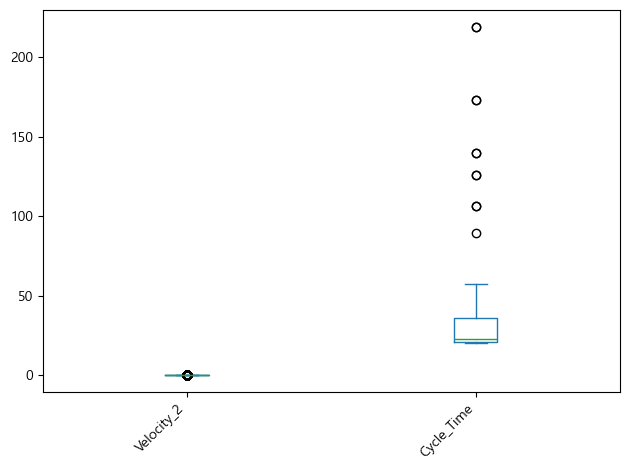

In [182]:
# 4) 시각화: 이상치 많은 컬럼 상위 6개 박스플롯
top_cols = outlier_count_by_col[outlier_count_by_col > 0].head(5).index

plt.figure(figsize=(12, 4))
X[top_cols].plot(kind="box")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [184]:
print("===== [Velocity_2, Cycle_Time] 컬럼 min/max =====")
print(X2[top_cols].agg(["min", "max"]))
print()

tmp = X2[top_cols].copy()
tmp["y"] = y

print("===== 불량/양품 평균(mean) 비교 =====")
print(tmp.groupby("y")[top_cols].mean())
print()

print("===== 불량/양품 중앙값(median) 비교 =====")
print(tmp.groupby("y")[top_cols].median())
print()

===== [Velocity_2, Cycle_Time] 컬럼 min/max =====
     Velocity_2  Cycle_Time
min       0.158        20.2
max       0.212       218.6

===== 불량/양품 평균(mean) 비교 =====
   Velocity_2  Cycle_Time
y                        
0    0.168863   27.247725
1    0.168583   29.425933

===== 불량/양품 중앙값(median) 비교 =====
   Velocity_2  Cycle_Time
y                        
0       0.168        22.5
1       0.168        35.0



### 이상치 IQR 보고
이상치 기준: IQR\
하한 = Q1 - 1.5×IQR\
상한 = Q3 + 1.5×IQR\
하한보다 작거나 상한보다 크면 이상치로 판단

1. 이상치가 1개라도 존재하는 행\
590 / 7,535 (약 7.83%)

2. 이상치가 많은 컬럼 TOP (개수 기준)
    1. Factory_Temp : 374개 (약 4.96%)
    2. Velocity_2 : 184개 (약 2.44%)
    3. Biscuit_Thickness : 12개
    4. Cycle_Time : 11개
    5. High_Velocity : 10개
    6. Rapid_Rise_Time : 10개
    7. 그 외 Velocity_1, Pressure_Rise_Time, Velocity_3, Cylinder_Pressure 등은 소수
    - 이상치는 Factory_Temp, Velocity_2에 상대적으로 많이 집중되어 있다.

3. 이상치 값 범위
    1. Factory_Temp: 27.4 ~ 37.0
    2. Velocity_2: 0.158 ~ 0.212
    3. Biscuit_Thickness: 0 ~ 24
    4. Cycle_Time: 20.2 ~ 218.6
    5. High_Velocity: 0.0 ~ 2.744
    - 0인 값들이 존재하기 때문에 측정 오류인지, 특정 상황인지 추후에 판단

4. 불량/양품 간 차이(참고: 평균·중앙값)
    - Cycle_Time, Biscuit_Thickness, High_Velocity는 불량(1)에서 더 큰 경향이 관찰된다
        - Biscuit_Thickness: 양품 13.0 → 불량 16.0
        - Cycle_Time: 양품 22.5 → 불량 35.0
        - High_Velocity: 양품 2.157 → 불량 2.506
    - 단순 이상치 보단 불량 신호일 가능성으로 볼수 있음

5. 판단
- IQR 기준 이상치는 행 기준 약 7.8% 수준, 특정 변수에 집중되어 있다.
- 현재 단계에서는 이상치가 불량 신호일 가능성도 존재한다.
- 제거/클리핑 처리는 추후 회의를 통해 결정

### 이상치 z-score

In [155]:
# =========================
# Z-score(6σ) 이상치 "확인" (표 + 그래프 합본)
# =========================

z_th = 6

# 1) 컬럼별 평균/표준편차
mu = X.mean(numeric_only=True)
sigma = X.std(numeric_only=True, ddof=0)

# 표준편차 0인 컬럼 제외
sigma_zero = (sigma == 0)

# 2) Z-score & 이상치 마스크
z = (X - mu) / sigma
z_abs = z.abs()
z_outlier_mask = (z_abs > z_th)
z_outlier_mask.loc[:, sigma_zero] = False

# 3) 컬럼별 이상치 개수/비율
z_count = z_outlier_mask.sum().sort_values(ascending=False)
z_ratio = (z_count / len(X)).sort_values(ascending=False)

print("===== [Z-score 6σ] 이상치 TOP 15: 개수 =====")
print(z_count.head(15))
print()

print("===== [Z-score 6σ] 이상치 TOP 15: 비율 =====")
print(z_ratio.head(15))
print()

rows_with_any = z_outlier_mask.any(axis=1).sum()
print("이상치가 1개라도 있는 행 수:", rows_with_any, "/", len(X))
print("비율:", rows_with_any / len(X))
print()

===== [Z-score 6σ] 이상치 TOP 15: 개수 =====
Velocity_2            34
Cycle_Time            11
Pressure_Rise_Time     4
High_Velocity          4
Shot                   0
Product_Type           0
Velocity_3             0
Velocity_1             0
Cylinder_Pressure      0
Rapid_Rise_Time        0
Clamping_Force         0
Biscuit_Thickness      0
Casting_Pressure       0
Spray_Time             0
Spray_1_Time           0
dtype: int64

===== [Z-score 6σ] 이상치 TOP 15: 비율 =====
Velocity_2            0.004512
Cycle_Time            0.001460
Pressure_Rise_Time    0.000531
High_Velocity         0.000531
Shot                  0.000000
Product_Type          0.000000
Velocity_3            0.000000
Velocity_1            0.000000
Cylinder_Pressure     0.000000
Rapid_Rise_Time       0.000000
Clamping_Force        0.000000
Biscuit_Thickness     0.000000
Casting_Pressure      0.000000
Spray_Time            0.000000
Spray_1_Time          0.000000
dtype: float64

이상치가 1개라도 있는 행 수: 45 / 7535
비율: 0.0059721300597213

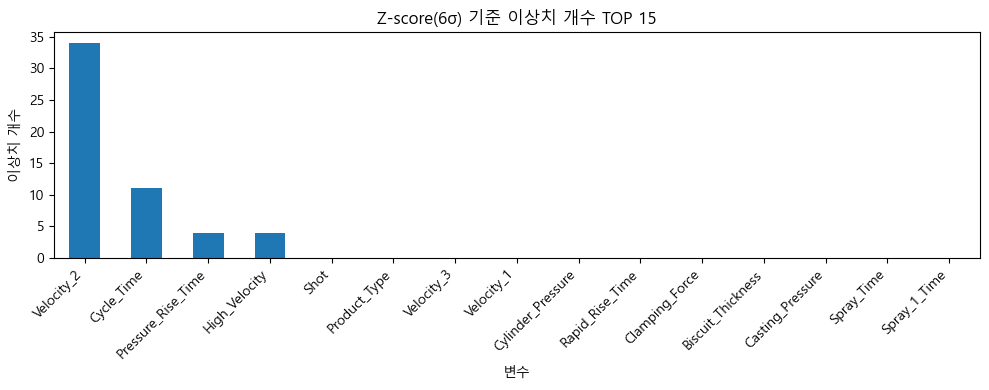

In [156]:
# 4) 그래프: TOP 15 막대그래프
top15 = z_count.head(15)

plt.figure(figsize=(10,4))
top15.plot(kind="bar")
plt.title("Z-score(6σ) 기준 이상치 개수 TOP 15")
plt.xlabel("변수")
plt.ylabel("이상치 개수")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [157]:
# =========================
# Z-score(3σ) 이상치 "확인" (표 + 그래프 합본)
# =========================

z_th = 3

# 1) 컬럼별 평균/표준편차
mu = X.mean(numeric_only=True)
sigma = X.std(numeric_only=True, ddof=0)

# 표준편차 0인 컬럼 제외
sigma_zero = (sigma == 0)

# 2) Z-score & 이상치 마스크
z = (X - mu) / sigma
z_abs = z.abs()
z_outlier_mask = (z_abs > z_th)
z_outlier_mask.loc[:, sigma_zero] = False

# 3) 컬럼별 이상치 개수/비율
z_count = z_outlier_mask.sum().sort_values(ascending=False)
z_ratio = (z_count / len(X)).sort_values(ascending=False)

print("===== [Z-score 3σ] 이상치 TOP 15: 개수 =====")
print(z_count.head(15))
print()

print("===== [Z-score 3σ] 이상치 TOP 15: 비율 =====")
print(z_ratio.head(15))
print()

rows_with_any = z_outlier_mask.any(axis=1).sum()
print("이상치가 1개라도 있는 행 수:", rows_with_any, "/", len(X))
print("비율:", rows_with_any / len(X))
print()

===== [Z-score 3σ] 이상치 TOP 15: 개수 =====
Velocity_2            144
Biscuit_Thickness      36
Rapid_Rise_Time        22
Velocity_1             22
Velocity_3             18
Cycle_Time             15
High_Velocity          14
Cylinder_Pressure       4
Pressure_Rise_Time      4
Factory_Temp            2
Product_Type            0
Clamping_Force          0
Casting_Pressure        0
Shot                    0
Spray_Time              0
dtype: int64

===== [Z-score 3σ] 이상치 TOP 15: 비율 =====
Velocity_2            0.019111
Biscuit_Thickness     0.004778
Rapid_Rise_Time       0.002920
Velocity_1            0.002920
Velocity_3            0.002389
Cycle_Time            0.001991
High_Velocity         0.001858
Cylinder_Pressure     0.000531
Pressure_Rise_Time    0.000531
Factory_Temp          0.000265
Product_Type          0.000000
Clamping_Force        0.000000
Casting_Pressure      0.000000
Shot                  0.000000
Spray_Time            0.000000
dtype: float64

이상치가 1개라도 있는 행 수: 223 / 7535
비율: 0.

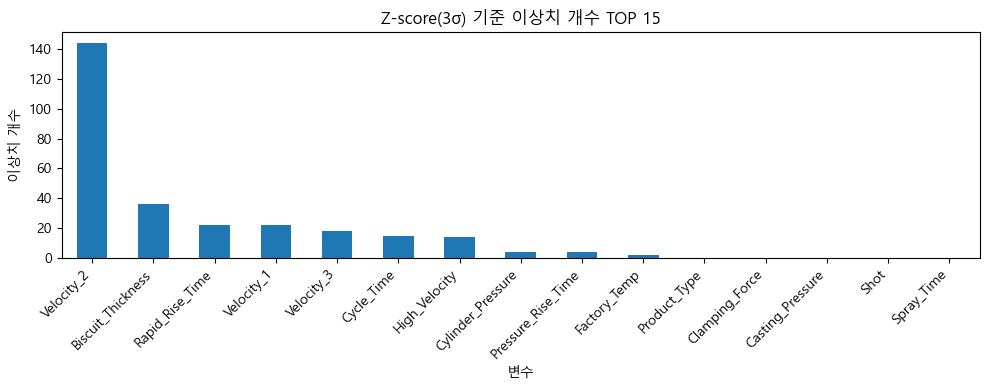

In [158]:
# 4) 그래프: TOP 15 막대그래프
top15 = z_count.head(15)

plt.figure(figsize=(10,4))
top15.plot(kind="bar")
plt.title("Z-score(3σ) 기준 이상치 개수 TOP 15")
plt.xlabel("변수")
plt.ylabel("이상치 개수")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 이상치 z-score 보고